## Setting Environment

In [2]:
import pandas as pd
import numpy as n
import networkx as nx
import matplotlib.pyplot as plt
import pickle

## Initialise Data

In [4]:
trade_Prev = pd.read_excel("export_2020m1.xlsx", skiprows=1, index_col=0, nrows=7)
trade_Prev

,Canada,France,Germany,Italy,Japan,United Kingdom,United States
Canada,NaN,259.774344,356.288051,158.939284,773.170192,1458.702675,26820.721998
France,269.969993,NaN,6440.928402,3525.584930,544.497147,2685.976457,3219.695959
Germany,931.950594,9628.673888,NaN,6253.252577,1863.955690,6717.742877,10086.173941
Italy,385.370044,4422.526669,5280.943382,NaN,718.988403,2248.973697,4146.895775
Japan,742.191653,482.307729,1487.667310,373.958913,NaN,1331.326120,9664.659178
United Kingdom,547.707600,2434.150113,4016.820126,984.401990,538.725446,NaN,6139.224086
United States,22550.409387,3494.204301,4718.306603,1742.348778,5454.467853,5832.579169,NaN


### Pre-Processing

In [6]:
trade_Prev = pd.melt(trade_Prev.reset_index(), id_vars='index')
trade_Prev.columns = ['exportCountry','importCountry','value']
trade_Prev.dropna(inplace=True)
trade_Prev.head()

,exportCountry,importCountry,value
1,France,Canada,269.969993
2,Germany,Canada,931.950594
3,Italy,Canada,385.370044
4,Japan,Canada,742.191653
5,United Kingdom,Canada,547.707600


## Create Network Graph Template

In [10]:
G_prev = nx.Graph()

for index, row in trade_Prev.iterrows():
    G_prev.add_edge(row['exportCountry'], row['importCountry'], weight=row['value'])

    remove = [node for node, degree in G_prev.degree() if degree==0]
    G_prev.remove_nodes_from(remove)

    settings={
     'node_color': 'lightblue',
     'edge_color': 'lightblue',
     'node_size': 1,
     'width': 1,
     'alpha': 1.0}

## Create Network Graph

### Function to Create Network Graph of Different Layout
1. Establish createNetGraph with input parameters network layout and data matrix
2. In the Function, initialise plot figure size
3. Define network layout of data matrix
4. Define network graph value, nodes, font size and network graph display setting
5. Set tight layout
6. Remove axis lines
7. Set title to network layout name
8. Display created network graph

In [77]:
def createNetGraph(layout, G):
    plt.subplots(figsize=(5,5))

    pos=layout(G)
    nx.draw(G, pos=pos, font_size=9, **settings)
    nx.draw_networkx_labels(G, pos=pos, font_size=9)
    plt.tight_layout()
    plt.axis('off')
    plt.title(f"{layout.__name__}")
    plt.show()    

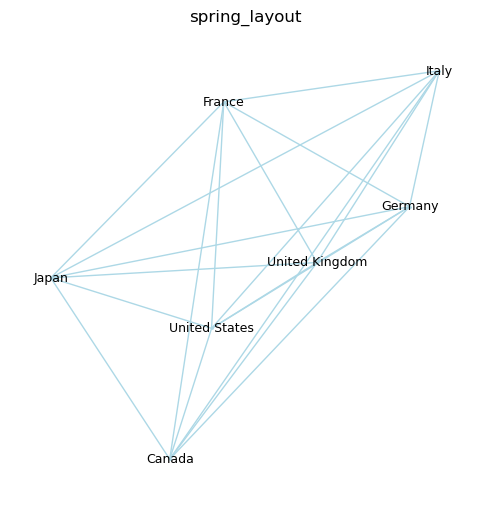

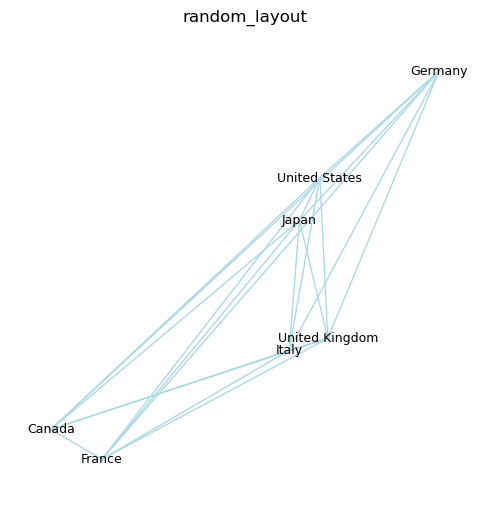

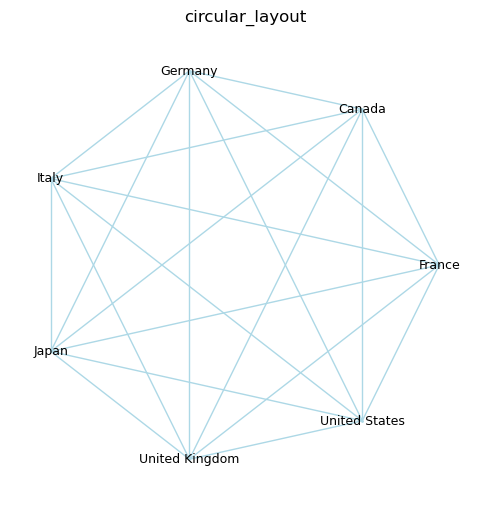

In [79]:
nxLayout_ls =[nx.spring_layout, nx.random_layout, nx.circular_layout]
for i in nxLayout_ls:
    createNetGraph(i,G_prev)

#### Load Back Latest Data Network Graph

In [12]:
f = open("graph.pickle","rb")
G_latest = pickle.load(f)
f.close()

### Compare Latest and Previous Network Graph
1. Plot 3 rows x 2 columns
2. Create a dictionary list of network layout
3. Create a dictionary list of latest and previous year data
4. Create an iteration to plot the  2 network graph base on layout.
5. Create a nested iterations to access 2 dictionary list
    1. Initialise first layout to use on graph.
    2. Draw out the network graph and position the graph accordingly
    3. Plot the graph in a tight layout.
    4. Hide graph x-axis.
    5. Set title for each graph base on layout and data used

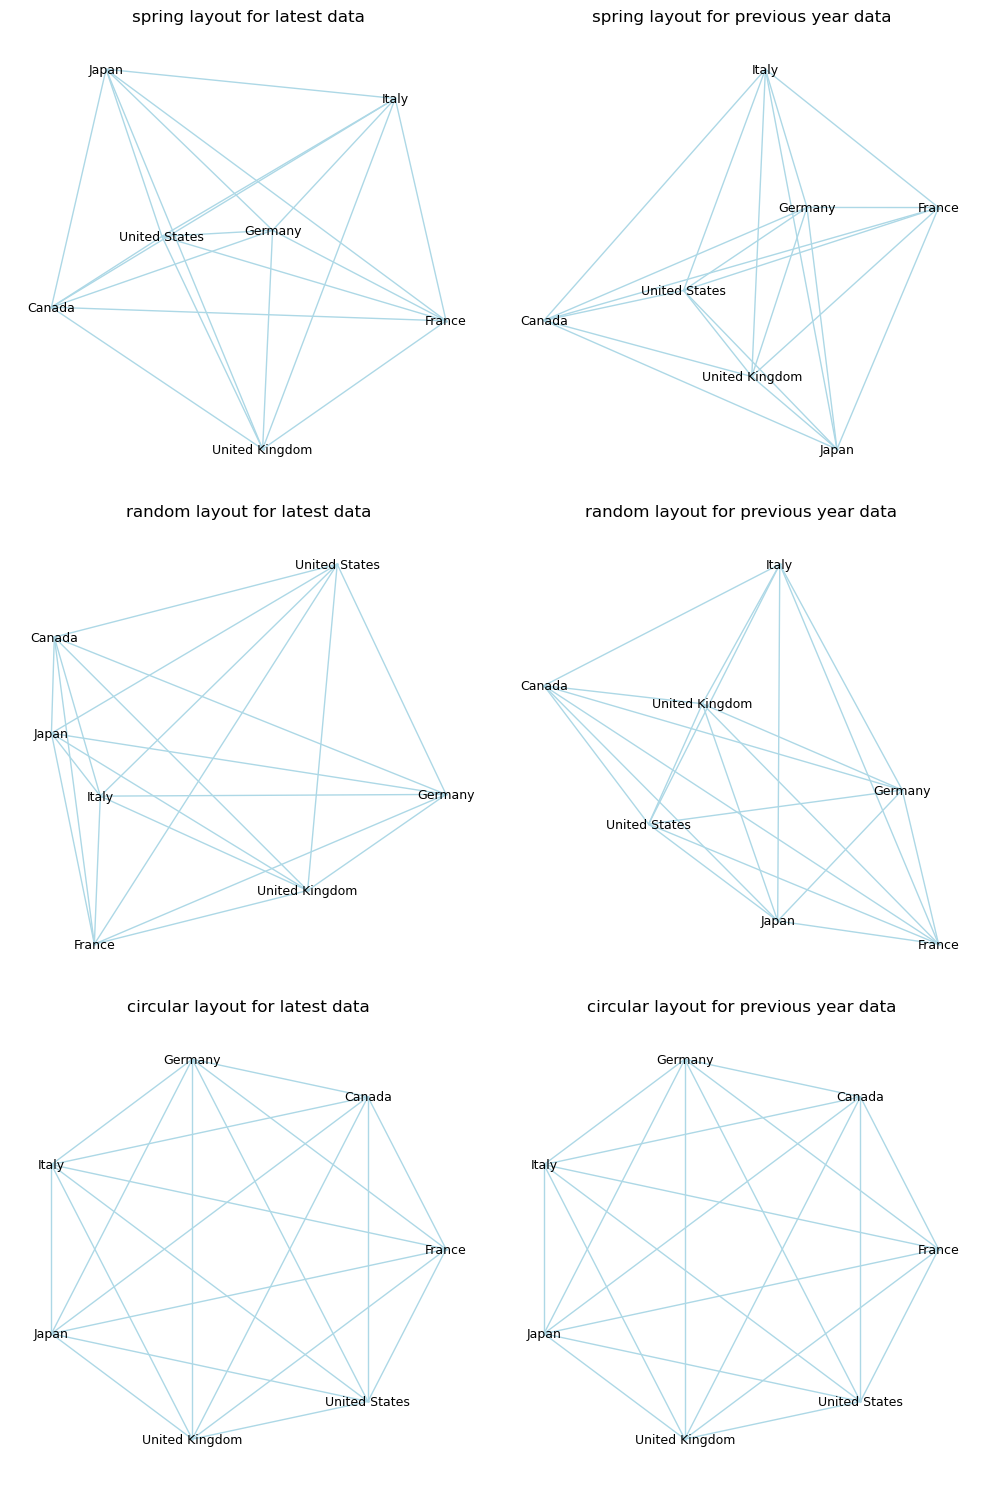

In [55]:
fig, ax = plt.subplots(3,2, figsize=(10,15))

layouts = {"spring": nx.spring_layout, "random": nx.random_layout, "circular": nx.circular_layout}
graphs = {"latest": G_latest, "previous year": G_prev}
for i, (layout_name, layout) in enumerate(layouts.items()):
    for j, (graph_name, graph) in enumerate(graphs.items()):
        pos=layout(graph)
        nx.draw_networkx(graph, pos=pos, ax=ax[i][j], font_size=9, **settings)
        plt.tight_layout()
        ax[i][j].set_axis_off()
        ax[i][j].set_title(f"{layout_name} layout for {graph_name} data")